# Fundamentals, Applied to the LattePanda Carrier Board — M.2 / PCIe Link

**A worked-example companion to Chapter 1 of Johnson & Graham's *High-Speed Digital Design***

This notebook takes the four tools from Chapter 1 — the knee frequency, the time/distance conversion,
the lumped-vs-distributed threshold, and the reactance-at-Fknee check — and runs them against the
actual M.2 (PCIe Gen3 x1/x2) link on the carrier board.

Every number below is computed live from the parameters in the next cell. **Change the parameters to
match your own board and every plot and printed value updates.** The values here are realistic
placeholders for a PCIe Gen3 link on FR-4 — swap in your real stackup and measured/simulated trace
lengths and this becomes a verification tool, not just an illustration.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ============================================================
# BOARD PARAMETERS — replace with your real LattePanda numbers
# ============================================================

# --- Signal / edge rate ---
Tr_ns          = 0.10      # 10-90% rise time, ns. PCIe Gen3 (8 GT/s) TX edges are commonly ~80-120 ps.
Tbit_ns        = 1 / 8.0   # unit interval at 8 GT/s = 125 ps

# --- Stackup / dielectric (placeholder: typical FR-4 M.2 carrier) ---
er_stripline   = 4.3       # inner-layer dielectric constant
er_microstrip  = 3.1       # effective er for outer-layer microstrip

# --- Routed geometry (PLACEHOLDER — measure these in your layout tool) ---
trace_len_in   = 1.8       # M.2 connector to SoC, inches, one-way
is_stripline   = True      # is this pair routed on an inner layer?

# --- Target impedance / termination ---
Z0_diff        = 85        # ohms, PCIe differential target
driver_Zout    = 45        # ohms, single-ended output impedance (rough, per leg)

# --- Via stub (PLACEHOLDER — from your via structure / backdrill depth) ---
via_L_nH       = 1.2       # nH, unbackdrilled stub self-inductance, rough estimate
via_C_pF       = 0.4       # pF, via pad parasitic capacitance, rough estimate

c_in_per_ns    = 11.8      # speed of light, in/ns

print(f"Edge rate Tr = {Tr_ns*1000:.0f} ps   |   Unit interval = {Tbit_ns*1000:.0f} ps")


Edge rate Tr = 100 ps   |   Unit interval = 125 ps


## 1. Knee frequency — what bandwidth actually matters here

$$F_{knee} = \frac{0.5}{T_r}$$

Everything downstream in this notebook gets evaluated at this one number. It's not the PCIe
8 GT/s symbol rate — it's set by the transmitter's edge rate, which is much faster than the bit
period suggests.


In [2]:

F_knee_GHz = 0.5 / Tr_ns  # Tr in ns -> F_knee in GHz

print(f"F_knee = {F_knee_GHz:.2f} GHz")
print(f"For comparison, the PCIe Gen3 symbol rate is {1/Tbit_ns:.1f} GT/s "
      f"(Nyquist ~{0.5/Tbit_ns:.2f} GHz)")
print(f"F_knee is ~{F_knee_GHz / (0.5/Tbit_ns):.1f}x higher than the Nyquist frequency of the bit rate.")


F_knee = 5.00 GHz
For comparison, the PCIe Gen3 symbol rate is 8.0 GT/s (Nyquist ~4.00 GHz)
F_knee is ~1.2x higher than the Nyquist frequency of the bit rate.


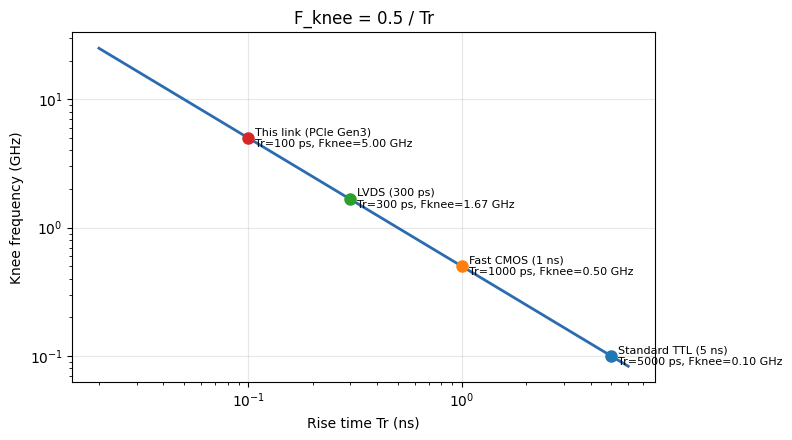

In [3]:

# Knee frequency vs rise time, with common logic families and this link marked
Tr_sweep = np.logspace(np.log10(0.02), np.log10(6), 300)  # 20 ps to 6 ns
Fknee_sweep = 0.5 / Tr_sweep

fig, ax = plt.subplots()
ax.loglog(Tr_sweep, Fknee_sweep, lw=2, color='#2b6cb0')

markers = {
    "Standard TTL (5 ns)": 5.0,
    "Fast CMOS (1 ns)": 1.0,
    "LVDS (300 ps)": 0.3,
    "This link (PCIe Gen3)": Tr_ns,
}
for label, tr in markers.items():
    fk = 0.5 / tr
    ax.plot(tr, fk, 'o', ms=8)
    ax.annotate(f"  {label}\n  Tr={tr*1000:.0f} ps, Fknee={fk:.2f} GHz",
                (tr, fk), fontsize=8, va='center')

ax.set_xlabel("Rise time Tr (ns)")
ax.set_ylabel("Knee frequency (GHz)")
ax.set_title("F_knee = 0.5 / Tr")
plt.tight_layout()
plt.show()


## 2. Time and distance — how long is the edge, physically

$$v = \frac{c}{\sqrt{\varepsilon_{r,eff}}} \qquad l = T_r \times v$$

This converts the rise time into a physical length on the board. It's the number that makes
"electrically short" a picture instead of an abstraction.


In [4]:

v_stripline  = c_in_per_ns / np.sqrt(er_stripline)     # in/ns
v_microstrip = c_in_per_ns / np.sqrt(er_microstrip)    # in/ns

edge_len_stripline  = Tr_ns * v_stripline
edge_len_microstrip = Tr_ns * v_microstrip

v_actual = v_stripline if is_stripline else v_microstrip
edge_len_actual = Tr_ns * v_actual
delay_per_in = 1000 / v_actual  # ps/in

print(f"Stripline velocity:  {v_stripline:.2f} in/ns  ({1000/v_stripline:.0f} ps/in)")
print(f"Microstrip velocity: {v_microstrip:.2f} in/ns ({1000/v_microstrip:.0f} ps/in)")
print()
print(f"Edge length, stripline:  {edge_len_stripline:.2f} in")
print(f"Edge length, microstrip: {edge_len_microstrip:.2f} in")
print()
routing = "stripline" if is_stripline else "microstrip"
print(f"This link is routed as {routing}: edge length = {edge_len_actual:.2f} in, "
      f"delay = {delay_per_in:.0f} ps/in")


Stripline velocity:  5.69 in/ns  (176 ps/in)
Microstrip velocity: 6.70 in/ns (149 ps/in)

Edge length, stripline:  0.57 in
Edge length, microstrip: 0.67 in

This link is routed as stripline: edge length = 0.57 in, delay = 176 ps/in


## 3. Lumped vs. distributed — is the M.2 trace a transmission line problem

$$L_{trace} < \frac{l}{6} = \frac{T_r \times v}{6}$$

If the actual routed length exceeds this, the trace needs transmission-line treatment:
controlled impedance, a real termination strategy, reflection budget — not just an RC
approximation.


In [5]:

critical_len_in = edge_len_actual / 6
delay_ns = trace_len_in / v_actual
threshold_ns = Tr_ns / 6

print(f"Critical length (1/6 rule): {critical_len_in:.3f} in")
print(f"Actual routed length:       {trace_len_in:.3f} in")
print(f"One-way delay of the trace: {delay_ns*1000:.1f} ps")
print(f"1/6 of the rise time:       {threshold_ns*1000:.1f} ps")
print()
if trace_len_in > critical_len_in:
    factor = trace_len_in / critical_len_in
    print(f"⚠ DISTRIBUTED: routed length is {factor:.1f}x past the critical length.")
    print("  This trace needs transmission-line treatment: controlled Z0, real termination,")
    print("  reflection budget. Lumped RC modeling will give you the wrong answer.")
else:
    print("✓ LUMPED: routed length is under the critical length. Ordinary R/L/C modeling holds.")


Critical length (1/6 rule): 0.095 in
Actual routed length:       1.800 in
One-way delay of the trace: 316.3 ps
1/6 of the rise time:       16.7 ps

⚠ DISTRIBUTED: routed length is 19.0x past the critical length.
  This trace needs transmission-line treatment: controlled Z0, real termination,
  reflection budget. Lumped RC modeling will give you the wrong answer.


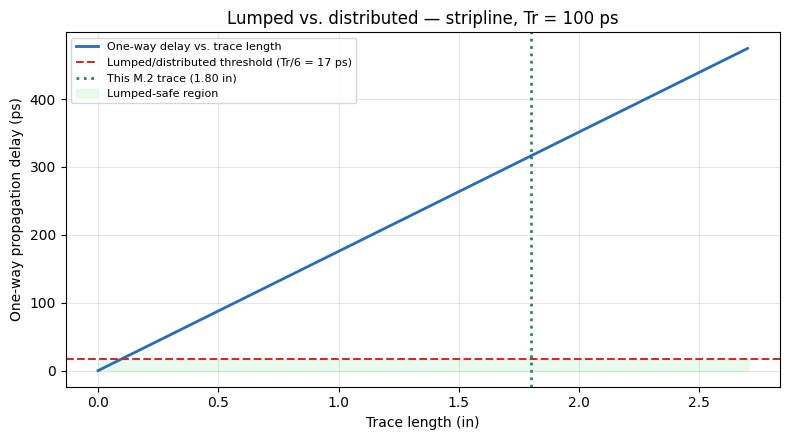

In [6]:

# Visualize: delay vs. length, with the 1/6-Tr threshold and this trace marked
lengths = np.linspace(0, max(critical_len_in * 3, trace_len_in * 1.5), 200)
delays_ps = (lengths / v_actual) * 1000

fig, ax = plt.subplots()
ax.plot(lengths, delays_ps, lw=2, color='#2b6cb0', label="One-way delay vs. trace length")
ax.axhline(threshold_ns * 1000, color='#c53030', ls='--', lw=1.5,
           label=f"Lumped/distributed threshold (Tr/6 = {threshold_ns*1000:.0f} ps)")
ax.axvline(trace_len_in, color='#2f855a', ls=':', lw=2,
           label=f"This M.2 trace ({trace_len_in:.2f} in)")
ax.fill_between(lengths, 0, threshold_ns * 1000, color='#c6f6d5', alpha=0.4, label="Lumped-safe region")

ax.set_xlabel("Trace length (in)")
ax.set_ylabel("One-way propagation delay (ps)")
ax.set_title(f"Lumped vs. distributed — {routing}, Tr = {Tr_ns*1000:.0f} ps")
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()


## 4. Reactance at F_knee — does the via stub actually matter

$$X_L = 2\pi F_{knee} L \qquad X_C = \frac{1}{2\pi F_{knee} C}$$

Evaluate the via's parasitic inductance and capacitance against the link's differential
impedance at F_knee. If both reactances are far from Z0, the via is a rounding error. If
either is comparable to Z0, it's a real discontinuity and belongs in the stackup review
(backdrill it, or don't — this is the number that decides).


In [7]:

F_knee_Hz = F_knee_GHz * 1e9
omega = 2 * np.pi * F_knee_Hz

X_L = omega * (via_L_nH * 1e-9)
X_C = 1 / (omega * (via_C_pF * 1e-12))

print(f"At F_knee = {F_knee_GHz:.2f} GHz:")
print(f"  Via stub inductive reactance  X_L = {X_L:.1f} ohm   (target Z0 = {Z0_diff} ohm)")
print(f"  Via pad capacitive reactance   X_C = {X_C:.1f} ohm   (target Z0 = {Z0_diff} ohm)")
print()
ratio_L = X_L / Z0_diff
ratio_C = X_C / Z0_diff
if ratio_L > 0.2 or ratio_C < 5:
    print("⚠ The via stub is a first-order discontinuity at this edge rate — model it, "
          "consider backdrilling.")
else:
    print("✓ The via stub's reactance is small relative to Z0 at F_knee — safe to simplify away.")


At F_knee = 5.00 GHz:
  Via stub inductive reactance  X_L = 37.7 ohm   (target Z0 = 85 ohm)
  Via pad capacitive reactance   X_C = 79.6 ohm   (target Z0 = 85 ohm)

⚠ The via stub is a first-order discontinuity at this edge rate — model it, consider backdrilling.


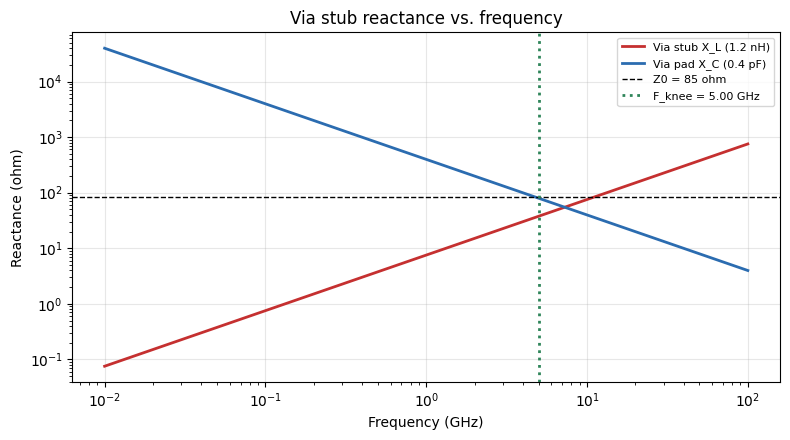

In [8]:

# Reactance vs frequency, with F_knee marked, showing where the via stops being negligible
freqs = np.logspace(7, 11, 400)  # 10 MHz to 100 GHz
XL_curve = 2 * np.pi * freqs * (via_L_nH * 1e-9)
XC_curve = 1 / (2 * np.pi * freqs * (via_C_pF * 1e-12))

fig, ax = plt.subplots()
ax.loglog(freqs / 1e9, XL_curve, label=f"Via stub X_L ({via_L_nH} nH)", lw=2, color='#c53030')
ax.loglog(freqs / 1e9, XC_curve, label=f"Via pad X_C ({via_C_pF} pF)", lw=2, color='#2b6cb0')
ax.axhline(Z0_diff, color='k', ls='--', lw=1, label=f"Z0 = {Z0_diff} ohm")
ax.axvline(F_knee_GHz, color='#2f855a', ls=':', lw=2, label=f"F_knee = {F_knee_GHz:.2f} GHz")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reactance (ohm)")
ax.set_title("Via stub reactance vs. frequency")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Swap in the real numbers

Everything above runs off the parameters cell at the top. To turn this from an illustration
into an actual verification of the LattePanda carrier board:

- [ ] Pull `trace_len_in` from the actual routed length in the layout tool (M.2 connector to SoC BGA)
- [ ] Confirm `er_stripline` / `er_microstrip` against the fab's stackup report, not the datasheet nominal
- [ ] Get `via_L_nH` / `via_C_pF` from a field solver or the fab's via model, not a rule-of-thumb estimate
- [ ] Confirm `Tr_ns` against the actual TX driver's datasheet spec, not the PCIe spec minimum

Once those are real, this notebook *is* the verification — not a description of one.
